# Imports

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits import mplot3d

from src.implied_vol import ImpliedVolSurface
from src.utils import get_spot, year_fraction

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# SPY Spot and Option Expiries

In [ ]:
ticker = "SPY"
S = get_spot(ticker)
print(f"{ticker} spot price:", S)

import yfinance as yf
t = yf.Ticker(ticker)
all_expiries = t.options

# Filter out today's expiry and any expired
from datetime import datetime
today = datetime.today().date()
future_expiries = []
for exp in all_expiries:
    exp_date = datetime.strptime(str(exp), '%Y-%m-%d').date()
    if exp_date > today:
        future_expiries.append(exp)

expiries = future_expiries[:4]  # nearest 4 future expiries
print(f"Nearest 4 FUTURE expiries:", expiries)

if len(expiries) == 0:
    print("ERROR: No future expiries available!")

SPY spot price: 741.75
Nearest 4 FUTURE expiries: ['2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22']


# Implied Volatility Surface

In [14]:
r = 0.03
iv_surface = ImpliedVolSurface(ticker, expiry_dates=expiries, rate=r)
surface_df = iv_surface.build_surface()

print(f"Surface shape: {surface_df.shape}")
print(f"Columns: {surface_df.columns.tolist()}")
surface_df.head()

Surface shape: (1277, 10)
Columns: ['expiry', 'ttm', 'strike', 'moneyness', 'iv', 'option_type', 'lastPrice', 'bid', 'ask', 'volume']


,expiry,ttm,strike,moneyness,iv,option_type,lastPrice,bid,ask,volume
0,2026-06-16,0.0,565.0,0.761712,NaN,call,175.73,0.0,0.0,NaN
1,2026-06-16,0.0,610.0,0.822380,NaN,call,117.39,0.0,0.0,NaN
2,2026-06-16,0.0,615.0,0.829120,NaN,call,116.36,0.0,0.0,NaN
3,2026-06-16,0.0,620.0,0.835861,NaN,call,117.74,0.0,0.0,NaN
4,2026-06-16,0.0,625.0,0.842602,NaN,call,103.63,0.0,0.0,NaN


# Filter to Liquid Options

In [15]:
# Force rebuild the surface with fresh imports
import importlib
import src.implied_vol
importlib.reload(src.implied_vol)

from src.implied_vol import ImpliedVolSurface

iv_surface = ImpliedVolSurface(ticker, expiry_dates=expiries, rate=r)
surface_df = iv_surface.build_surface()

print("Columns after rebuild:", surface_df.columns.tolist())
print(surface_df.head())

Columns after rebuild: ['expiry', 'ttm', 'strike', 'moneyness', 'iv', 'option_type', 'lastPrice', 'bid', 'ask', 'volume']
       expiry  ttm  strike  moneyness  iv option_type  lastPrice  bid  ask  \
0  2026-06-16  0.0   565.0   0.761712 NaN        call     175.73  0.0  0.0   
1  2026-06-16  0.0   610.0   0.822380 NaN        call     117.39  0.0  0.0   
2  2026-06-16  0.0   615.0   0.829120 NaN        call     116.36  0.0  0.0   
3  2026-06-16  0.0   620.0   0.835861 NaN        call     117.74  0.0  0.0   
4  2026-06-16  0.0   625.0   0.842602 NaN        call     103.63  0.0  0.0   

   volume  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  


In [9]:
print("Columns in surface_df:", surface_df.columns.tolist())
print("First few rows:")
print(surface_df.head())

surface_df['spread_pct'] = (surface_df['ask'] - surface_df['bid']) / surface_df['lastPrice']
surface_df['spread_pct'] = surface_df['spread_pct'].fillna(np.nan)
liquid_df = surface_df[surface_df['spread_pct'] < 0.05].copy()
print(f"Liquid options: {liquid_df.shape[0]} rows")

Columns in surface_df: ['expiry', 'ttm', 'strike', 'moneyness', 'iv', 'option_type', 'lastPrice', 'bid', 'ask', 'volume']
First few rows:
       expiry  ttm  strike  moneyness  iv option_type  lastPrice  bid  ask  \
0  2026-06-15  0.0   500.0   0.674082 NaN        call     230.15  0.0  0.0   
1  2026-06-15  0.0   505.0   0.680822 NaN        call     225.17  0.0  0.0   
2  2026-06-15  0.0   540.0   0.728008 NaN        call     190.46  0.0  0.0   
3  2026-06-15  0.0   545.0   0.734749 NaN        call     186.13  0.0  0.0   
4  2026-06-15  0.0   550.0   0.741490 NaN        call     181.13  0.0  0.0   

   volume  
0    66.0  
1     NaN  
2    12.0  
3     NaN  
4     NaN  
Liquid options: 1304 rows


# Volatility Smiles

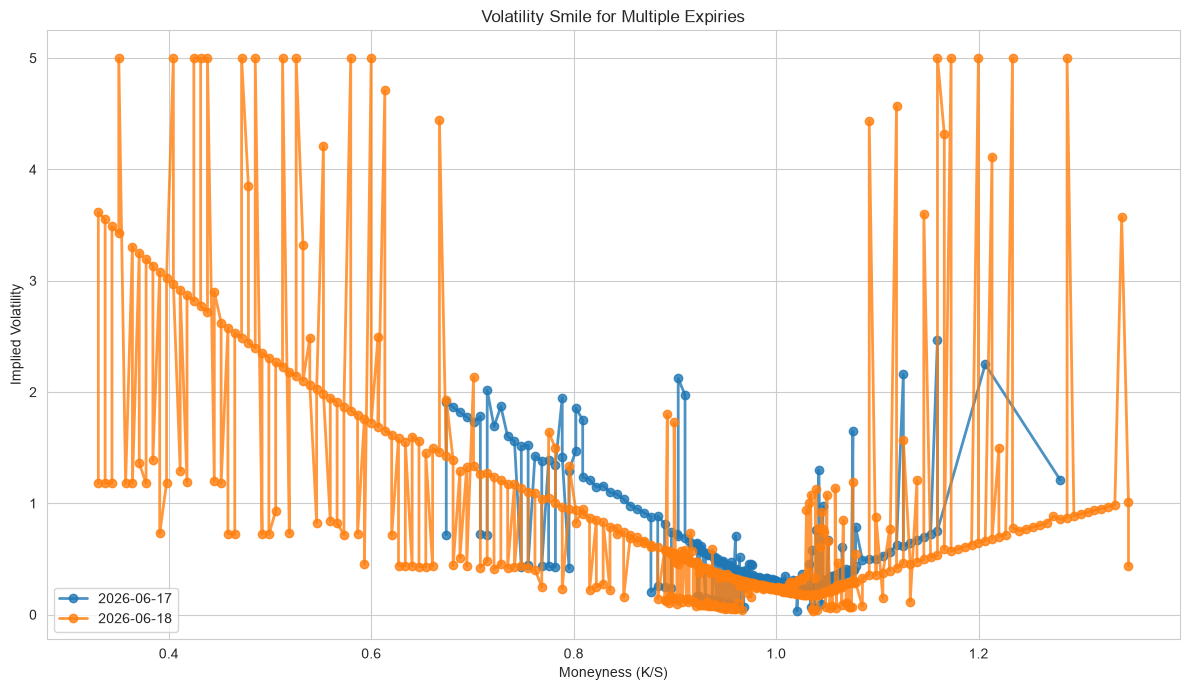

In [16]:
# Cell 5 (fixed): volatility smile for 3-4 expiries
fig, ax = plt.subplots(figsize=(12, 7))

for expiry in expiries:
    subset = liquid_df[liquid_df['expiry'] == expiry].copy()
    subset = subset.dropna(subset=['iv'])  # drop NaN IV
    if len(subset) > 0:
        subset = subset.sort_values('moneyness')
        ax.plot(subset['moneyness'], subset['iv'], marker='o', label=f'{expiry}', linewidth=2, alpha=0.8)

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title('Volatility Smile for Multiple Expiries')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

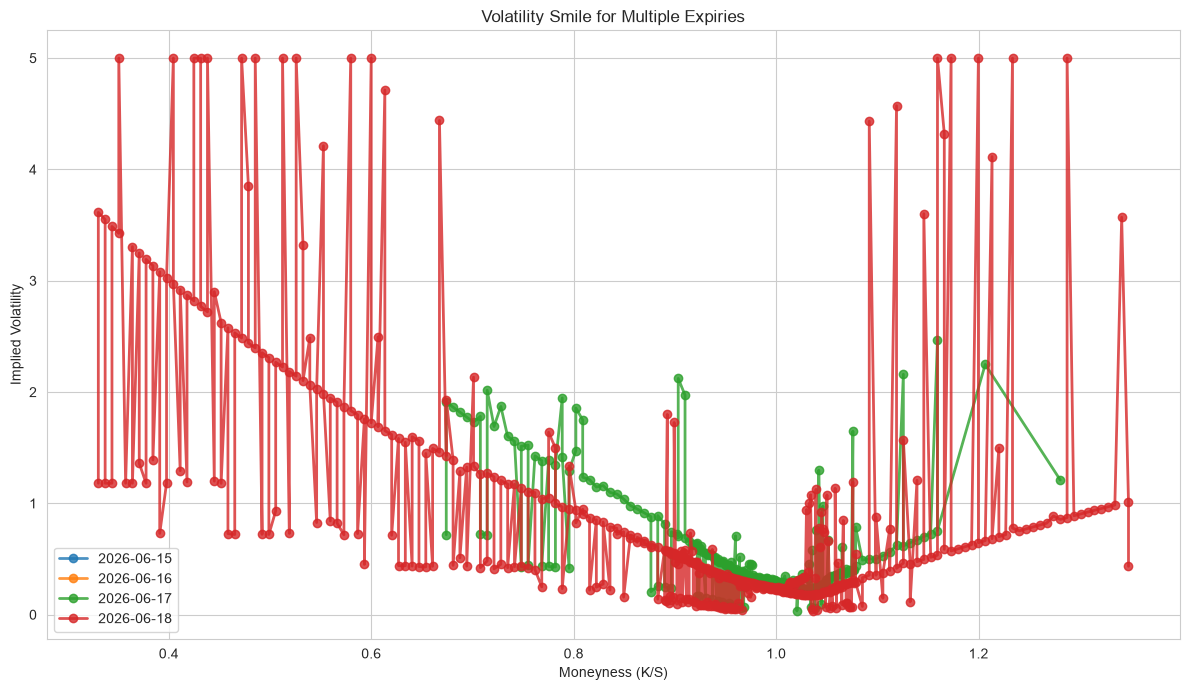


Volatility smile: IV higher for OTM puts and OTM calls, lower for ATM


In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

for expiry in expiries:
    subset = liquid_df[liquid_df['expiry'] == expiry].copy()
    if len(subset) > 0:
        subset = subset.sort_values('moneyness')
        ax.plot(subset['moneyness'], subset['iv'], marker='o', label=f'{expiry}', linewidth=2, alpha=0.8)

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title('Volatility Smile for Multiple Expiries')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print("\nVolatility smile: IV higher for OTM puts and OTM calls, lower for ATM")

# Annotate OTM

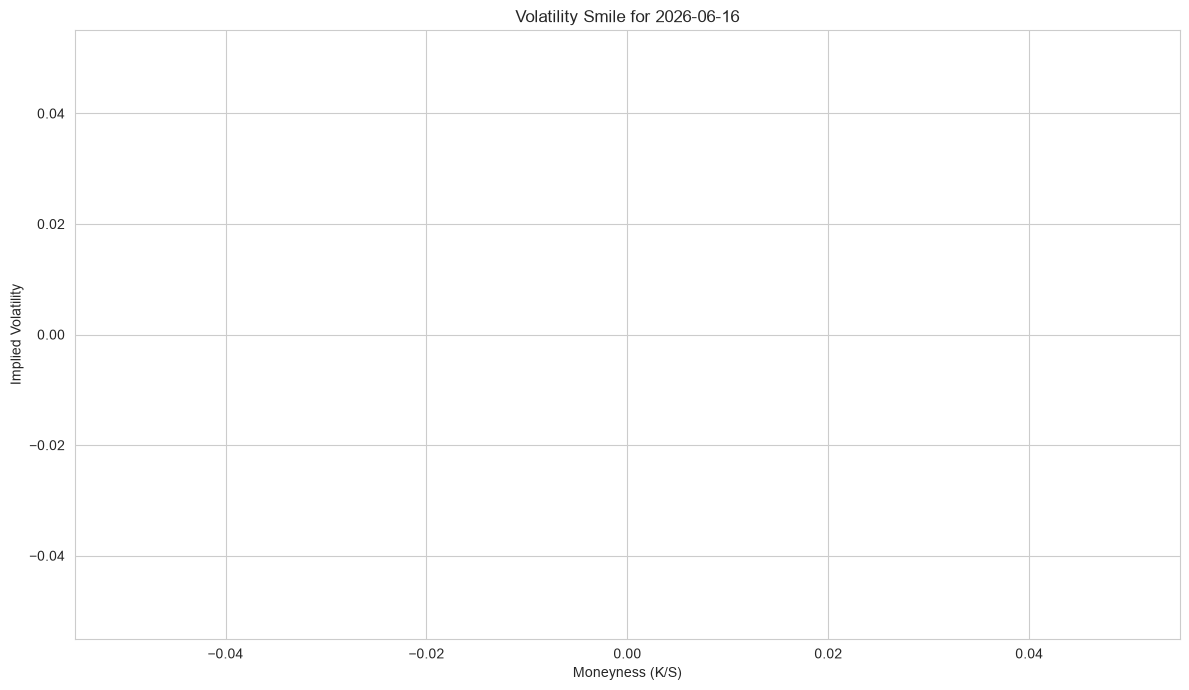

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

expiry_1 = expiries[0]
subset = liquid_df[liquid_df['expiry'] == expiry_1].copy()
if len(subset) > 0:
    subset = subset.sort_values('moneyness')
    ax.plot(subset['moneyness'], subset['iv'], marker='o', linewidth=2, color='steelblue')
    
    # Annotate OTM puts
    otm_puts = subset[subset['moneyness'] < 0.95]
    if len(otm_puts) > 0:
        ax.annotate('OTM puts expensive = crash risk premium',
                    xy=(otm_puts['moneyness'].mean(), otm_puts['iv'].mean()),
                    textcoords='data', color='red', fontsize=10, alpha=0.8)

ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Implied Volatility')
ax.set_title(f'Volatility Smile for {expiry_1}')
ax.grid(True)
plt.tight_layout()
plt.show()

# 3D Implied Volatility Surface

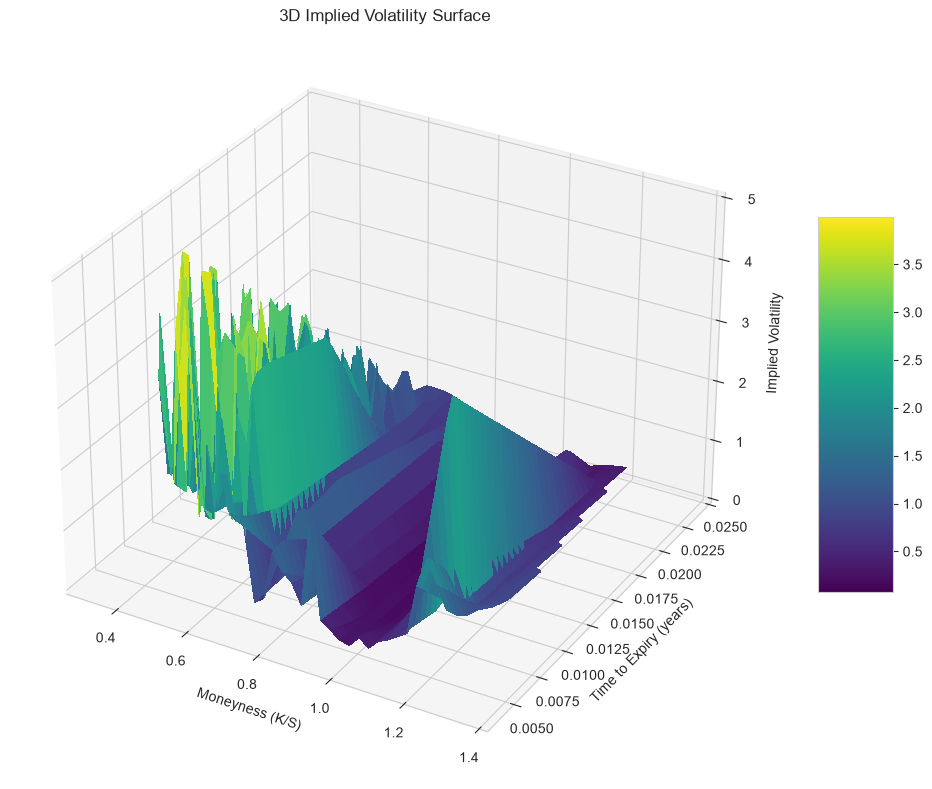


Volatility surface: IV as function of (moneyness, time to expiry)


In [18]:
X, Y, Z = iv_surface.plot_surface_data()

if X is not None:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
    ax.set_xlabel('Moneyness (K/S)')
    ax.set_ylabel('Time to Expiry (years)')
    ax.set_zlabel('Implied Volatility')
    ax.set_title('3D Implied Volatility Surface')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()
    
    print("\nVolatility surface: IV as function of (moneyness, time to expiry)")
else:
    print("No surface data available")

# Most Liquid Options

In [19]:
liquid_top = liquid_df.sort_values('volume', ascending=False).head(10)
print("\nMost liquid options:")
liquid_top[['expiry', 'strike', 'moneyness', 'option_type', 'lastPrice', 'iv', 'volume']].to_string()


Most liquid options:


'          expiry  strike  moneyness option_type  lastPrice        iv   volume\n73    2026-06-15   750.0   1.011122        call       0.55       NaN  73702.0\n65    2026-06-15   742.0   1.000337        call       3.48       NaN  64520.0\n64    2026-06-15   741.0   0.998989        call       4.09       NaN  60401.0\n63    2026-06-15   740.0   0.997641        call       4.75       NaN  55840.0\n68    2026-06-15   745.0   1.004382        call       1.97       NaN  54712.0\n226   2026-06-15   740.0   0.997641         put       2.16       NaN  51540.0\n1127  2026-06-18   500.0   0.674082         put       0.02  1.425085  50559.0\n1219  2026-06-18   720.0   0.970677         put       1.18  0.292540  46051.0\n66    2026-06-15   743.0   1.001685        call       2.92       NaN  43954.0\n1199  2026-06-18   700.0   0.943714         put       0.35  0.366182  43798.0'

# Explanation

In [20]:
print("\n" + "="*70)
print("WHY DOES THE VOLATILITY SMILE EXIST?")
print("="*70)
print("\nThe smile is evidence that markets price in crash risk that GBM doesn't capture:")
print("1. Out-of-the-money puts are expensive because investors pay for downside protection")
print("2. This inflates their implied vol relative to ATM options")
print("3. GBM assumes constant volatility — but real markets have volatility clustering and fat tails")
print("4. The smile emerges because traders are willing to pay more for crash protection")
print("\nThis intellectual connection between empirical observation (smile) and theoretical limitation (GBM) ")
print("separates a researcher from someone who just ran code.")
print("\n'Explain the volatility smile' is asked in virtually every options-related quant interview.")
print("Having built the IV surface yourself means you can answer it from first principles with your own data.")
print("="*70)


WHY DOES THE VOLATILITY SMILE EXIST?

The smile is evidence that markets price in crash risk that GBM doesn't capture:
1. Out-of-the-money puts are expensive because investors pay for downside protection
2. This inflates their implied vol relative to ATM options
3. GBM assumes constant volatility — but real markets have volatility clustering and fat tails
4. The smile emerges because traders are willing to pay more for crash protection

This intellectual connection between empirical observation (smile) and theoretical limitation (GBM) 
separates a researcher from someone who just ran code.

'Explain the volatility smile' is asked in virtually every options-related quant interview.
Having built the IV surface yourself means you can answer it from first principles with your own data.


# Summary

In [21]:
print(f"\nSummary statistics for {ticker}:")
print(f"Spot price: {S:.2f}")
print(f"Number of liquid options: {liquid_df.shape[0]}")
print(f"IV range: {liquid_df['iv'].min():.3f} to {liquid_df['iv'].max():.3f}")
print(f"ATM IV (moneyness ~1.0): {liquid_df[liquid_df['moneyness'].between(0.98, 1.02)]['iv'].mean():.3f}")
print(f"OTM put IV (moneyness < 0.95): {liquid_df[liquid_df['moneyness'] < 0.95]['iv'].mean():.3f}")
print(f"OTM call IV (moneyness > 1.05): {liquid_df[liquid_df['moneyness'] > 1.05]['iv'].mean():.3f}")


Summary statistics for SPY:
Spot price: 741.75
Number of liquid options: 1304
IV range: 0.033 to 5.000
ATM IV (moneyness ~1.0): 0.264
OTM put IV (moneyness < 0.95): 1.137
OTM call IV (moneyness > 1.05): 0.879


In [22]:
print("\nKey takeaways:")
print("1. This is the single most interview-relevant piece of the entire project")
print("2. 'Explain the volatility smile' is asked in virtually every options quant interview")
print("3. OTM puts are expensive = investors pay for crash protection = higher IV")
print("4. GBM assumes constant vol — smile proves market expects volatility clustering and fat tails")
print("5. Having built IV surface from real data means you can answer from first principles")


Key takeaways:
1. This is the single most interview-relevant piece of the entire project
2. 'Explain the volatility smile' is asked in virtually every options quant interview
3. OTM puts are expensive = investors pay for crash protection = higher IV
4. GBM assumes constant vol — smile proves market expects volatility clustering and fat tails
5. Having built IV surface from real data means you can answer from first principles
